Nous allons maintenant tester la stabilité du modèle. Pour ce faire, nous allons suivre le protocole suivant :

Réentraîner le modèle K-means sur les 12 premiers mois des données (vs près de 23 mois disponibles).

Vérifier que le nombre de K clusters sur la période de 12 mois reste le même que pour l'ensemble des données.

Puis, de manière itérative sur les données restantes :

Ajouter un mois de données

Centrer-réduire les données

Afficher l’indice de silhouette

Utiliser HDBSCAN à la place de l’indice de Davies-Bouldin,  afin d’évaluer la qualité des clusters

Utiliser le modèle K-means (non réentraîné) afin de prédire les clusters auxquels appartiennent les nouvelles données

Réentraîner le modèle K-means sur la nouvelle période étendue

Afficher l’indice de silhouette et appliquer à nouveau HDBSCAN après entraînement pour évaluer la qualité des clusters

Utiliser le modèle K-means réentraîné afin de prédire les clusters

Afficher l’indice de Rand ajusté comparant les clusters attribués aux données avant et après réentraînement. Cette dernière analyse sera réalisée uniquement sur les clients des 12 premiers mois afin de vérifier dans quelle proportion ils restent affectés au même cluster.

Les données comportent bien les utilisateurs qui ont réalisé des achats entre le 3 octobre 2016 et le 30 septembre 2017. Nous entraînons maintenant le modèles K-means en testant une fenêtre de clusters entre 2 et 10 afin de vérifier que sur 12 mois, l'indice de silhouette le plus élevé est atteint avec 4 clusters.

Index(['Unnamed: 0', 'identifiant_client', 'identifiant_unique_client',
       'code_postal_client', 'ville_client', 'état_client',
       'identifiant_commande', 'statut_commande', 'horodatage_achat_commande',
       'date_commande', 'heure_commande', 'année', 'mois', 'mois_année',
       'jour', 'paiement_séquentiel', 'type_paiement', 'nombre_paiements',
       'montant_paiement', 'identifiant_avis', 'note_avis',
       'identifiant_article_commande', 'identifiant_produit',
       'identifiant_vendeur', 'prix', 'frais_livraison', 'code_postal_vendeur',
       'ville_vendeur', 'état_vendeur', 'categorie_produit',
       'cp_etats_clients'],
      dtype='object')
Proportion des données sur 12 mois: 27.45%
Affichage des 10 premières valeurs du dataset


,Unnamed: 0,identifiant_client,identifiant_unique_client,code_postal_client,ville_client,état_client,identifiant_commande,statut_commande,horodatage_achat_commande,heure_commande,...,identifiant_article_commande,identifiant_produit,identifiant_vendeur,prix,frais_livraison,code_postal_vendeur,ville_vendeur,état_vendeur,categorie_produit,cp_etats_clients
0,0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,São Paulo,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,15:05:35,...,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,8577,itaquaquecetuba,SP,Maison,1000
5,5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,Santa Catarina,5741ea1f91b5fbab2bd2dc653a5b5099,delivered,2017-09-14 18:14:31,18:14:31,...,1.0,0be701e03657109a8a4d5168122777fb,8f2ce03f928b567e3d56181ae20ae952,259.90,22.31,5141,pirituba,SP,Sport & Loisirs,88000
12,12,b2d1536598b73a9abd18e0d75d92f0a3,918dc87cd72cd9f6ed4bd442ed785235,18682,lencois paulista,São Paulo,83d8f70418eefd96f37b483dff430305,delivered,2017-09-09 09:54:57,09:54:57,...,1.0,3fc00af0f0a8d4ac2933d3900416c977,7a241947449cc45dbfda4f9d0798d9d0,99.00,18.31,37590,jacutinga,MG,Maison,1000
19,19,154c4ded6991bdfa3cd249d11abf4130,e607ede0e63436308660236f5a52da5e,88034,florianopolis,Santa Catarina,830d8b3e6875ef6165ffc33219ab4fea,delivered,2017-08-13 10:03:36,10:03:36,...,1.0,130482add9fd75ccb6c57ba007694a2d,87142160b41353c4e5fca2360caf6f92,105.00,18.00,90230,porto alegre,RS,Informatique & Électronique,88000
24,24,237098a64674ae89babdc426746260fc,4390ddbb6276a66ff1736a6710205dca,82820,curitiba,Paraná,eac4ffbe456464bdc3ce5f001b6439c5,delivered,2017-04-14 11:24:56,11:24:56,...,1.0,a298a105818dce6878b787e4af6cff7d,e26901d5ab434ce92fd9b5c256820a4e,79.90,14.73,9350,maua,SP,Bébés,80000
28,28,6e359a57a91f84095cc64e1b351aef8c,2e6a42a9b5cbb0da62988694f18ee295,4571,sao paulo,São Paulo,a8f5a2b22f55e0af45b300929d1fdc7d,delivered,2017-05-15 17:58:25,17:58:25,...,1.0,11b062c710beb867b4897ff2728e828d,ae8bfdbf1c2a2a2dee92d799db0a31c6,29.99,17.60,85900,toledo,PR,Maison,1000
31,31,261cb4f92498ca05d5bd1a327a261d9c,424aca6872c5bab80780a8dec03b7516,12235,sao jose dos campos,São Paulo,2904d3ae0064e840ffb4798ba4a12ae3,delivered,2017-09-12 08:00:03,08:00:03,...,1.0,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,59.90,13.44,15025,sao jose do rio preto,SP,Bricolage & Jardin,1000
34,34,b2bed119388167a954382cca36c4777f,e079b18794454de9d2be5c12b4392294,27525,resende,Rio de Janeiro,77b062be7c5bd21712905feb8e1cfeed,delivered,2017-06-14 18:31:54,18:31:54,...,1.0,6421588f55f75de28cb3357e07723d14,1900267e848ceeba8fa32d80c1a5f5a8,56.99,16.13,14940,ibitinga,SP,Maison,20000
35,35,b2bed119388167a954382cca36c4777f,e079b18794454de9d2be5c12b4392294,27525,resende,Rio de Janeiro,77b062be7c5bd21712905feb8e1cfeed,delivered,2017-06-14 18:31:54,18:31:54,...,2.0,17606c7d7254ed1f0351fd48a28be932,1900267e848ceeba8fa32d80c1a5f5a8,44.99,16.14,14940,ibitinga,SP,Maison,20000
39,39,54f755c3fd2709231f9964a1430c5218,40febde16f4718a5def537786473b0be,93415,novo hamburgo,Rio Grande do Sul,d4668cd8ef48b78df597195703c95da2,delivered,2017-08-10 13:01:54,13:01:54,...,1.0,48633254f8b7b802b1ca8c4f4dcf3e33,8c16d1f32a54d92897cc437244442e1b,44.90,15.10,89023,blumenau,SC,Maison,90000


Affichage des 10 dernières valeurs du dataset


,Unnamed: 0,identifiant_client,identifiant_unique_client,code_postal_client,ville_client,état_client,identifiant_commande,statut_commande,horodatage_achat_commande,heure_commande,...,identifiant_article_commande,identifiant_produit,identifiant_vendeur,prix,frais_livraison,code_postal_vendeur,ville_vendeur,état_vendeur,categorie_produit,cp_etats_clients
111653,111653,059f60d3b37627f51e73eec500dfa1a8,db634985638ec4b6abf8734d7adde1ab,82800,curitiba,Paraná,eb5265687d8744ff9d5147004298fb36,delivered,2017-06-23 10:55:02,10:55:02,...,1.0,c0deba3200aa657c933dae7109403ad1,0eaa7e33d73809f1f925f7d07c506cbd,129.00,15.66,9111,santo andre,SP,Jouets,80000
111657,111657,b6ab7cabd5b094d098e1a1557a6d3f0d,a2325193ac2e95b805642e3100f80af3,11630,ilhabela,São Paulo,648c8fc147248b2db527bd25821f67af,delivered,2017-06-12 10:34:29,10:34:29,...,1.0,0176bf7839ab4e611dc01cdc3ef6f4e4,12b9676b00f60f3b700e83af21824c0e,199.00,20.63,95780,montenegro,RS,Gadgets,1000
111665,111665,e98998055b4804137a020830903f93f2,e097d846931763789c3fd00b27f3c325,3057,sao paulo,São Paulo,34041ba8694b6808060aafda57f6075e,delivered,2017-03-20 18:33:07,18:33:07,...,1.0,1ce0e963805e3c170485768e8b09fe65,7722b1df1b0e383e000397b2c11e3e19,39.90,11.74,9715,sao bernardo do campo,SP,Maison,1000
111669,111669,da37711b17efd5f2539e8196ab215f04,5f2971f9805e3ccb030226e30c8e8390,4313,sao paulo,São Paulo,c8203bb57639618630affac9e8e923dd,delivered,2017-03-27 23:04:18,23:04:18,...,1.0,aea06073397f809424f946979354c9f0,f45122a9ab94eb4f3f8953578bc0c560,19.99,10.96,13419,piracicaba,SP,Animaux,1000
111683,111683,a1b5ca506b592bb72d4caadcbfe71385,c811311629fd3d76f5ca5eeb2abfa7e8,17511,marilia,São Paulo,65f3d65b89d1fdde15dc314858c9c161,delivered,2017-04-10 00:08:56,00:08:56,...,1.0,a1250bbcaa645885c9165eab1573b5c6,6560211a19b47992c3666cc44a7e94c0,47.99,10.96,5849,sao paulo,SP,Mode,1000
111684,111684,be631308cb609ff74d0e0fb54815e18c,1c137fe37df712015f6488edafe8ece4,36255,aracitaba,Minas Gerais,b7ae7c643ef9274727f48dcb0ba08593,delivered,2017-01-25 16:51:27,16:51:27,...,1.0,43f88c8353708451babf9bcdd1fda92a,cab85505710c7cb9b720bceb52b01cee,49.90,14.52,2252,sao paulo,SP,Mode,30000
111688,111688,e5ed7280cd1a3ac2ba29fd6650d8867c,206e64e8af2633a2ebe158a7fcb860db,8560,poa,São Paulo,53cbf33b674d602f6746cb90a9d874fd,delivered,2017-05-15 17:42:38,17:42:38,...,1.0,35afc973633aaeb6b877ff57b2793310,4a3ca9315b744ce9f8e9374361493884,89.90,12.13,14940,ibitinga,SP,Maison,1000
111692,111692,ffa6d90c36a9c7004692ca50761c69d6,874c93d867b18eb09a5e2f071ee89458,13140,paulinia,São Paulo,2816b0ec050fb4a136c32a6bda007a91,delivered,2017-03-27 16:26:18,16:26:18,...,1.0,32267de030005084d4b6af64f22143b8,9dda5bbacd45e18d6485fee649205d09,110.00,20.85,37540,santa rita do sapucai,MG,Maison,1000
111694,111694,27b9b32173455ef32167540451749d0b,277490f0d435b602fe4475d4b89e9181,6727,cotia,São Paulo,326c29ec5b89834b17aea7d85302fd70,delivered,2017-05-24 11:54:31,11:54:31,...,1.0,99a4788cb24856965c36a24e339b6058,4a3ca9315b744ce9f8e9374361493884,89.90,12.13,14940,ibitinga,SP,Maison,1000
111697,111697,14308d2303a3e2bdf4939b86c46d2679,e7f8760e2bbd2f1986bebd99596c088e,66033,belem,Pará,ec3a75fb0ac595e461765d2d854b1d08,delivered,2017-03-15 21:04:08,21:04:08,...,1.0,6b5af19067eeadc0f331687a79ca656b,bf0045791395e66460eb04749c68672a,59.90,24.42,4256,sao paulo,SP,Papeterie,66000


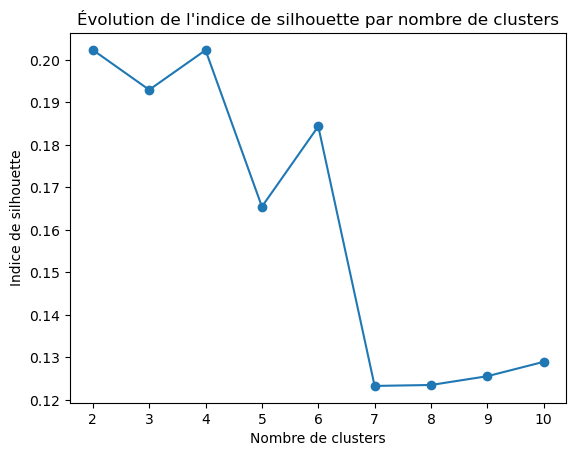

In [ ]:
# Importation des bibliothèques
import pandas as pd
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler  # ✅ Import manquant
import matplotlib.pyplot as plt

# Chargement du fichier CSV
df = pd.read_csv('df_all.csv')
print(df.columns)  # Vérification des noms de colonnes

# Conversion de la colonne de date
df['date_commande'] = pd.to_datetime(df['date_commande'])

# Filtrage des commandes avant octobre 2017
df_12_months = df[df['date_commande'] < pd.to_datetime('2017-10-01')].copy()  # ✅ Ajout de .copy()
df_12_months.drop(columns='date_commande', inplace=True)

# Calcul de la proportion de commandes sur cette période
prop_12_months = round((df_12_months.shape[0] / df.shape[0] * 100), 2)
print(f"Proportion des données sur 12 mois: {prop_12_months}%")

# Affichage des 10 premières et 10 dernières lignes du sous-ensemble
print("Affichage des 10 premières valeurs du dataset")
display(df_12_months.head(10))

print("Affichage des 10 dernières valeurs du dataset")
display(df_12_months.tail(10))

# Sélection des colonnes numériques uniquement
df_12_months_num = df_12_months.select_dtypes(include=['float64', 'int64'])

# Standardisation des données
scaler = StandardScaler()
df_12_months_std = scaler.fit_transform(df_12_months_num)

# Analyse de l’indice de silhouette pour évaluer le bon nombre de clusters
silhouettes_df_12_months = []

for nb_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=nb_clusters, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(df_12_months_std)
    silh = metrics.silhouette_score(df_12_months_std, kmeans.labels_)
    silhouettes_df_12_months.append(silh)

# Visualisation de l'évolution de l'indice de silhouette
plt.plot(range(2, 11), silhouettes_df_12_months, marker='o')
plt.xticks(range(2, 11))
plt.xlabel('Nombre de clusters')
plt.ylabel('Indice de silhouette')
plt.title("Évolution de l'indice de silhouette par nombre de clusters")
plt.show()


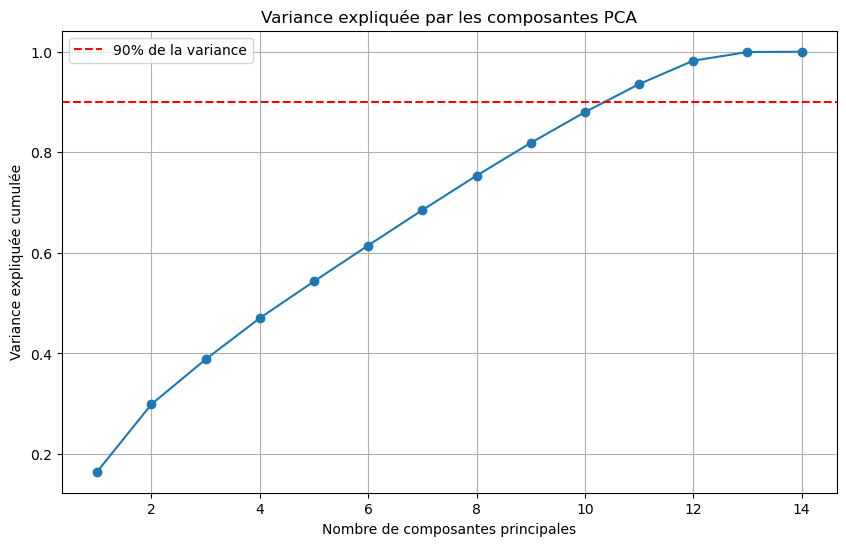

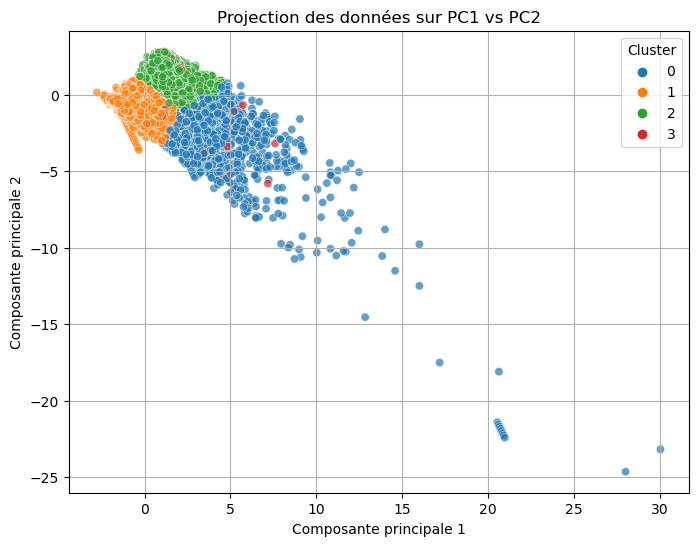

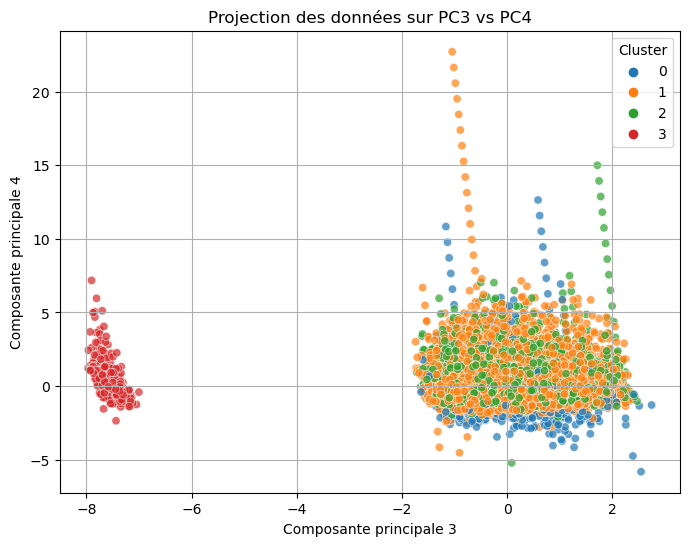

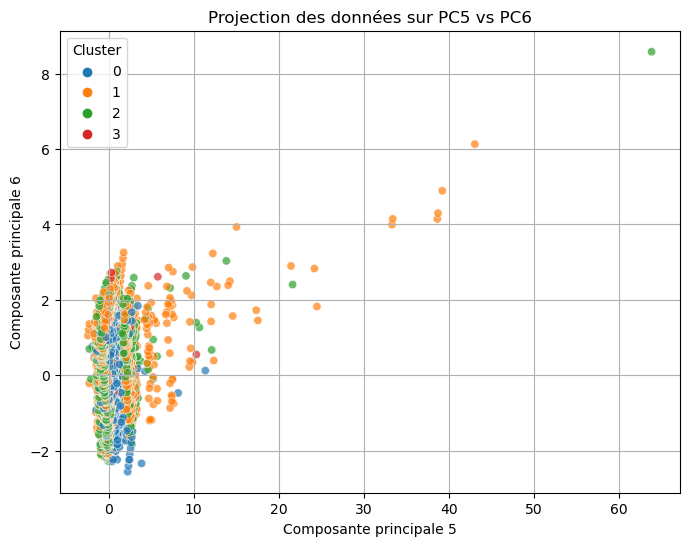

Poids (charges) des variables dans les composantes principales :


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
Unnamed: 0,-0.016,0.017,0.019,-0.122,-0.215,0.923,-0.212,0.170,0.001,-0.084,-0.060,0.016,-0.020,0.000
code_postal_client,0.433,0.539,0.000,0.061,-0.021,-0.015,-0.061,0.012,0.040,-0.005,-0.028,-0.110,0.014,-0.707
année,-0.025,0.003,0.659,-0.027,-0.048,-0.012,-0.212,-0.084,0.170,0.040,0.687,-0.087,0.007,-0.000
mois,0.003,-0.013,-0.599,-0.062,-0.079,-0.107,-0.167,0.467,-0.094,-0.105,0.588,-0.091,0.025,-0.001
jour,-0.006,-0.012,0.436,0.151,-0.064,-0.160,-0.041,0.691,-0.472,-0.066,-0.223,0.024,0.014,-0.000
paiement_séquentiel,-0.021,0.012,-0.012,-0.076,0.871,0.119,-0.310,0.154,0.029,0.308,-0.038,-0.053,-0.035,-0.001
nombre_paiements,0.248,-0.201,-0.053,0.023,-0.301,0.026,0.042,0.039,-0.095,0.884,0.024,-0.065,-0.075,0.003
montant_paiement,0.416,-0.418,0.020,0.117,0.035,-0.023,-0.072,0.039,0.160,-0.259,-0.067,-0.293,-0.668,-0.003
note_avis,-0.046,0.047,0.073,-0.576,-0.155,-0.209,-0.056,0.368,0.620,0.062,-0.223,0.112,-0.033,0.003
identifiant_article_commande,0.040,-0.094,-0.020,0.697,0.053,0.101,0.162,0.267,0.540,0.036,0.029,0.227,0.216,-0.002


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import metrics

# 1. Chargement des données
df = pd.read_csv('df_all.csv')
df['date_commande'] = pd.to_datetime(df['date_commande'])

# 2. Sélection des 12 premiers mois
df_12_months = df[df['date_commande'] < pd.to_datetime('2017-10-01')].copy()
df_12_months.drop(columns='date_commande', inplace=True)

# 3. Sélection des colonnes numériques
df_12_months_num = df_12_months.select_dtypes(include=['float64', 'int64'])

# 4. Standardisation
scaler = StandardScaler()
df_12_months_std = scaler.fit_transform(df_12_months_num)

# 5. Clustering KMeans
cls_df_12_months = KMeans(n_clusters=4, init='k-means++', random_state=42)
cls_df_12_months.fit(df_12_months_std)

# 6. PCA
pca = PCA()
pca_coords = pca.fit_transform(df_12_months_std)

# 7. Analyse de la variance expliquée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o')
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée par les composantes PCA")
plt.axhline(y=0.90, color='r', linestyle='--', label='90% de la variance')
plt.grid(True)
plt.legend()
plt.show()

# 8. Données PCA + clusters
df_pca_all = pd.DataFrame(
    pca_coords,
    columns=[f'PC{i+1}' for i in range(pca_coords.shape[1])]
)
df_pca_all['cluster'] = cls_df_12_months.labels_

# 9. Visualisation des paires de composantes
pairs = [(0, 1), (2, 3), (4, 5)]

for (i, j) in pairs:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=df_pca_all[f'PC{i+1}'],
        y=df_pca_all[f'PC{j+1}'],
        hue=df_pca_all['cluster'],
        palette='tab10',
        alpha=0.7
    )
    plt.title(f"Projection des données sur PC{i+1} vs PC{j+1}")
    plt.xlabel(f"Composante principale {i+1}")
    plt.ylabel(f"Composante principale {j+1}")
    plt.grid(True)
    plt.legend(title='Cluster')
    plt.show()

# 10. Charges (poids) des variables dans les composantes principales
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_12_months_num.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("Poids (charges) des variables dans les composantes principales :")
display(loadings.round(3))


Même si la volumétrie des données est différente on distingue déjà le même type de formes que pour l'ensemble des données. Nous précédont à présent aux traitements sur les mois restants.

## Version  KMEANS

Période de 13 mois se terminant avant le 2017-11-01:
Proportion du jeu de données: 32.16%
Silhouette avant : 0.198, après : 0.171
Davies-Bouldin avant : 1.535, après : 2.179
Indice Rand ajusté (ARI) : 0.671
------------------------------------------------------------------------------------------------------------------------------------------------------

Période de 14 mois se terminant avant le 2017-12-01:
Proportion du jeu de données: 39.85%
Silhouette avant : 0.192, après : 0.167
Davies-Bouldin avant : 1.574, après : 1.919
Indice Rand ajusté (ARI) : 0.753
------------------------------------------------------------------------------------------------------------------------------------------------------

Période de 15 mois se terminant avant le 2018-01-01:
Proportion du jeu de données: 45.43%
Silhouette avant : 0.188, après : 0.140
Davies-Bouldin avant : 1.587, après : 1.946
Indice Rand ajusté (ARI) : 0.512
---------------------------------------------------------------------------

C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


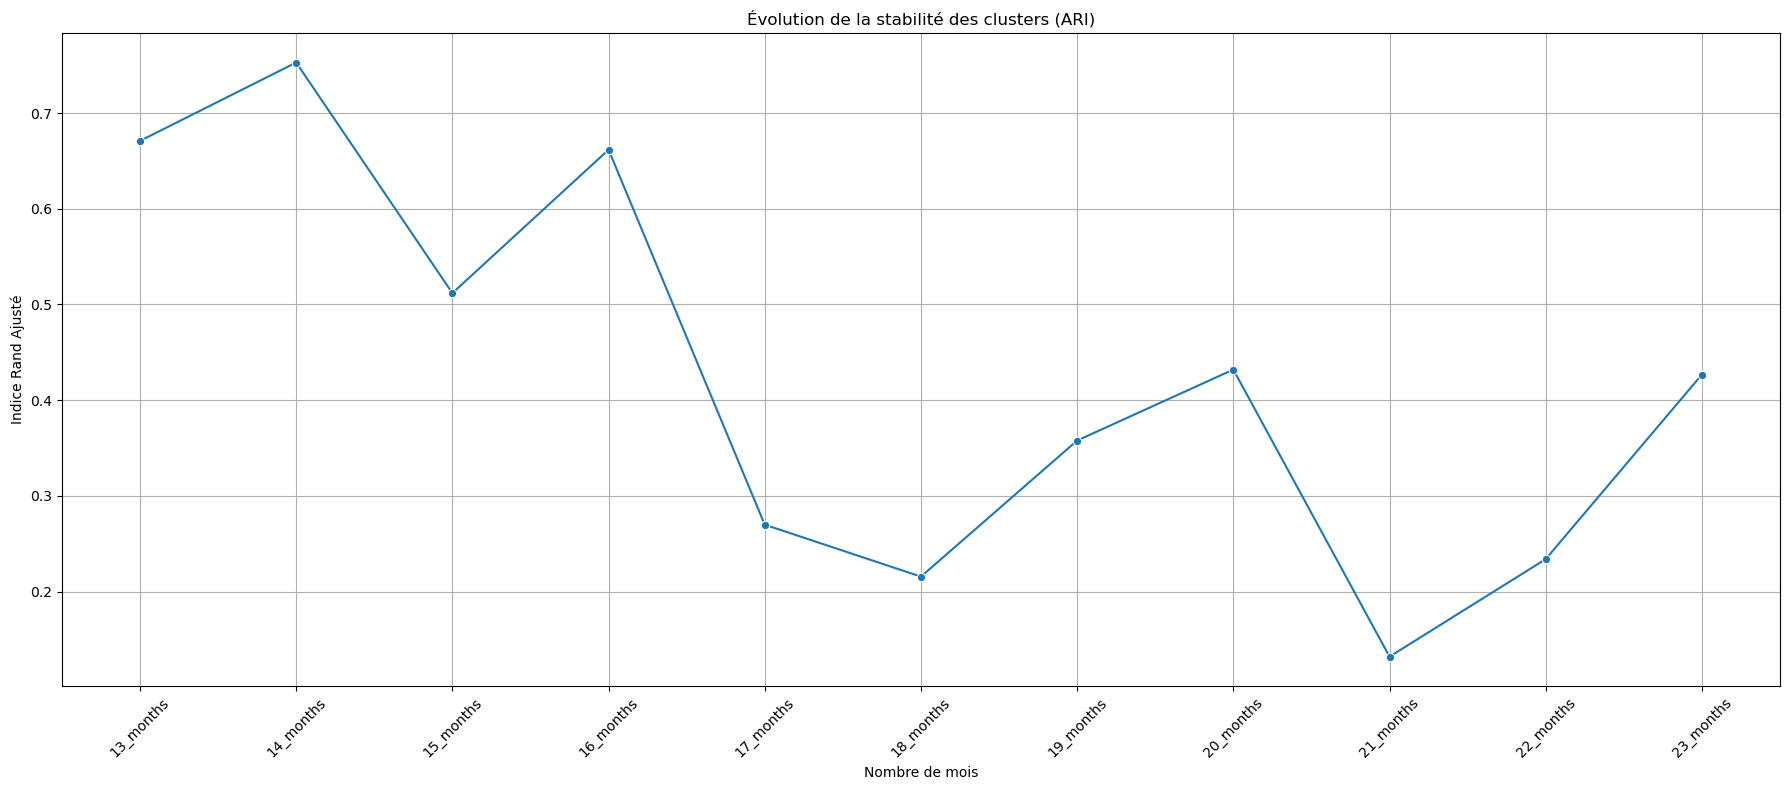

In [ ]:
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sélection stricte des colonnes numériques de référence
df_12_months_num = df_12_months.select_dtypes(include=['float64', 'int64'])
cols_to_use = df_12_months_num.columns.tolist()

# Standardisation sur les données initiales
scaler = StandardScaler()
df_12_months_std = pd.DataFrame(
    scaler.fit_transform(df_12_months_num),
    columns=cols_to_use,
    index=df_12_months.index
)

# Modèle initial
model = KMeans(n_clusters=4, init='k-means++', random_state=42)
model.fit(df_12_months_std)

results_res = []
time_bounds = [
    '2017-11-01', '2017-12-01', '2018-01-01', '2018-02-01',
    '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01',
    '2018-07-01', '2018-08-01', '2018-09-01'
]

labels_limit = len(df_12_months_std)  # nombre d'instances de référence

for i, bound in enumerate(time_bounds):
    month_res = {}

    # Filtrage des données jusqu’à la borne temporelle
    df_month = df[df['date_commande'] < pd.to_datetime(bound)].copy()
    df_month.drop(columns='date_commande', inplace=True)

    # Colonnes numériques sélectionnées
    df_month_num = df_month[cols_to_use]

    prop_data_period = round((df_month.shape[0] / df.shape[0] * 100), 2)

    # Standardisation
    df_month_std = pd.DataFrame(
        scaler.transform(df_month_num),
        columns=cols_to_use,
        index=df_month.index
    )

    # Prédictions avec le modèle entraîné initialement
    labels_before_fit = model.predict(df_month_std)
    silh_before_fit = metrics.silhouette_score(df_month_std, labels_before_fit)
    db_before_fit = metrics.davies_bouldin_score(df_month_std, labels_before_fit)

    # Réentraînement du modèle
    fitted_model = KMeans(n_clusters=4, init='k-means++', random_state=42)
    fitted_model.fit(df_month_std)
    labels_after_fit = fitted_model.predict(df_month_std)
    silh_after_fit = metrics.silhouette_score(df_month_std, labels_after_fit)
    db_after_fit = metrics.davies_bouldin_score(df_month_std, labels_after_fit)

    # Calcul de l'indice Rand ajusté
    ari = adjusted_rand_score(
        labels_before_fit[:labels_limit],
        labels_after_fit[:labels_limit]
    )

    # Stockage des résultats
    month_res['time_bound'] = bound
    month_res['dataframe'] = df_month
    month_res['standardized_dataframe'] = df_month_std
    month_res['prop_data_period'] = prop_data_period
    month_res['labels_before_fit'] = labels_before_fit[:labels_limit]
    month_res['silh_before_fit'] = silh_before_fit
    month_res['db_before_fit'] = db_before_fit
    month_res['fitted_model'] = fitted_model
    month_res['labels_after_fit'] = labels_after_fit[:labels_limit]
    month_res['silh_after_fit'] = silh_after_fit
    month_res['ari'] = ari

    results_res.append(month_res)

    print(f"Période de {i+13} mois se terminant avant le {bound}:")
    print(f"Proportion du jeu de données: {prop_data_period}%")
    print(f"Silhouette avant : {silh_before_fit:.3f}, après : {silh_after_fit:.3f}")
    print(f"Davies-Bouldin avant : {db_before_fit:.3f}, après : {db_after_fit:.3f}")
    print(f"Indice Rand ajusté (ARI) : {ari:.3f}")
    print("-" * 150 + "\n")

# Résumé global
results_df = pd.DataFrame(results_res)

# Visualisation
months = [
    '13_months', '14_months', '15_months', '16_months',
    '17_months', '18_months', '19_months', '20_months',
    '21_months', '22_months', '23_months'
]

plt.figure(figsize=(18, 8))
sns.lineplot(x=months, y=results_df['ari'], marker='o')
plt.xlabel("Nombre de mois")
plt.ylabel("Indice Rand Ajusté")
plt.title("Évolution de la stabilité des clusters (ARI)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Version HDBSCAN

In [ ]:
#pip install --upgrade hdbscan


13 mois → silhouette avant/après = 0.575/0.137, DB = 1.734/1.749, ARI = 0.371
14 mois → silhouette avant/après = 0.565/0.131, DB = 1.725/1.787, ARI = 0.341
15 mois → silhouette avant/après = 0.561/0.129, DB = 1.729/1.716, ARI = 0.336
16 mois → silhouette avant/après = 0.563/0.130, DB = 0.674/1.743, ARI = 0.862
17 mois → silhouette avant/après = 0.567/0.131, DB = 0.668/1.727, ARI = 0.899
18 mois → silhouette avant/après = 0.569/0.133, DB = 0.668/1.699, ARI = 0.914
19 mois → silhouette avant/après = 0.570/0.133, DB = 0.669/1.694, ARI = 0.921
20 mois → silhouette avant/après = 0.570/0.133, DB = 0.671/1.689, ARI = 0.925
21 mois → silhouette avant/après = 0.569/0.133, DB = 0.674/1.699, ARI = 0.928
22 mois → silhouette avant/après = 0.567/0.130, DB = 0.678/1.699, ARI = 0.928
23 mois → silhouette avant/après = 0.566/0.128, DB = 0.681/1.644, ARI = 0.924


C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


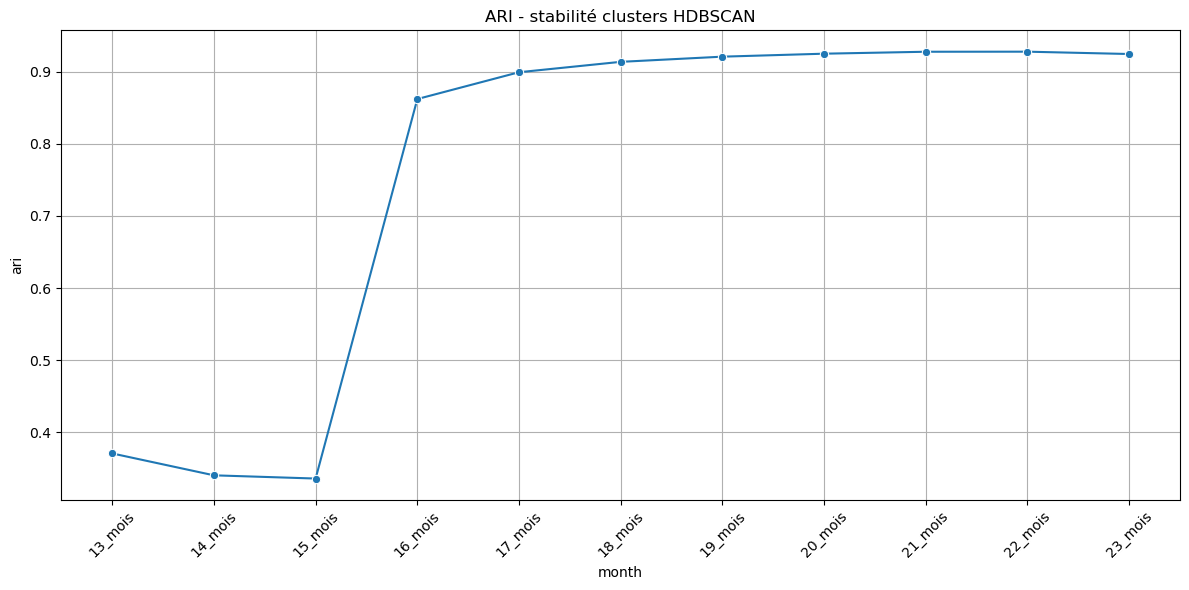

CPU times: total: 1h 56min 39s
Wall time: 1h 17min 46s


In [ ]:
%%time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    adjusted_rand_score, silhouette_score, davies_bouldin_score
)
import hdbscan
from hdbscan import approximate_predict  # ✅ bon import

# --- 1. Standardisation initiale sur 12 mois
df_12_months_num = df_12_months.select_dtypes(include=['float64', 'int64'])
scaler = StandardScaler().fit(df_12_months_num)
scaler_features = df_12_months_num.columns.tolist()

df_12_months_std = pd.DataFrame(
    scaler.transform(df_12_months_num),
    columns=scaler_features, index=df_12_months.index
)

# --- 2. Modèle initial HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=300, min_samples=70,
    cluster_selection_epsilon=0.8, prediction_data=True
).fit(df_12_months_std)

# --- 3. Boucle d’analyse mensuelle
results = []
time_bounds = [
    '2017-11-01', '2017-12-01', '2018-01-01', '2018-02-01',
    '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01',
    '2018-07-01', '2018-08-01', '2018-09-01'
]
labels_limit = len(clusterer.labels_)

for i, bound in enumerate(time_bounds):
    dfm = df[df['date_commande'] < bound].drop(columns='date_commande', errors='ignore')
    dfm = dfm[df_12_months.columns]
    dfm_num = dfm[scaler_features]
    dfm_std = pd.DataFrame(scaler.transform(dfm_num), columns=scaler_features, index=dfm.index)

    labels_before, strengths = approximate_predict(clusterer, dfm_std)
    silh_before = silhouette_score(dfm_std, labels_before)
    db_before = davies_bouldin_score(dfm_std, labels_before)

    fitted = hdbscan.HDBSCAN(min_cluster_size=10, prediction_data=True).fit(dfm_std)
    labels_after = fitted.labels_
    silh_after = silhouette_score(dfm_std, labels_after)
    db_after = davies_bouldin_score(dfm_std, labels_after)

    ari = adjusted_rand_score(labels_before[:labels_limit], labels_after[:labels_limit])

    results.append({
        'month': f"{13+i}_mois", 'prop': round(len(dfm)/len(df)*100,2),
        'silh_before': silh_before, 'db_before': db_before,
        'silh_after': silh_after, 'db_after': db_after, 'ari': ari
    })
    print(f"{13+i} mois → silhouette avant/après = {silh_before:.3f}/{silh_after:.3f}, DB = {db_before:.3f}/{db_after:.3f}, ARI = {ari:.3f}")

# --- 4. Visualisation ARI
res_df = pd.DataFrame(results)
plt.figure(figsize=(12,6))
sns.lineplot(x='month', y='ari', data=res_df, marker='o')
plt.xticks(rotation=45); plt.title("ARI - stabilité clusters HDBSCAN"); plt.grid(); plt.tight_layout()
plt.show()


Points-clés :
1. Qualité de la séparation (Silhouette / DB)
KMeans : qualité de cluster baisse fortement avec le temps.

HDBSCAN : meilleure qualité initiale (Silhouette > 0.55), légèrement dégradée après clustering, mais beaucoup plus stable.

Davies-Bouldin (plus faible = meilleur) montre que HDBSCAN maintient mieux la compacité des clusters.

2. Stabilité temporelle (ARI)
KMeans : ARI très instable (0.75 à 0.13).

HDBSCAN : ARI très stable dès 16 mois (> 0.86), et jusqu’à 0.928 !

3. Proportion de données
HDBSCAN performe très bien dès 16 mois (52%) de données. KMeans est meilleur uniquement autour de 14 mois (ARI = 0.753) mais s'effondre ensuite.

Modèle recommandé: HDBSCAN
Robuste aux variations dans le temps.

Meilleure qualité globale des clusters.

Plus apte à détecter des formes de clusters non sphériques, ce qui est utile si les clients ont des comportements atypiques.

Moins sensible aux outliers (contrairement à KMeans).

Proposition de contrat de maintenance
 Fréquence recommandée : tous les 6 mois
Justification :
Stabilité du clustering (ARI) : > 0.9 entre 18 et 23 mois → le modèle garde ses segments cohérents pendant au moins 6 mois.

Un rythme trimestriel serait excessif vu la stabilité observée.

Un rythme annuel risquerait de manquer certains changements marketing ou saisonniers.

Contenu du contrat de maintenance proposé :
Audit du modèle (tous les 6 mois) :

Vérification de la stabilité via ARI.

Réévaluation des clusters sur les données les plus récentes.

Recalibrage du clustering si l'ARI chute sous 0.85.

Mise à jour des étiquettes clients.

Livrable marketing : description de chaque segment mise à jour.

Exploitation marketing
Exemple de segments (à définir via HDBSCAN + features) :
Clients réguliers et très satisfaits → ciblage par offres de fidélité.

Clients peu actifs mais satisfaits → campagnes de réactivation.

Clients insatisfaits ou passifs → exclusion de certaines campagnes, ou enquête qualitative.

Valeur ajoutée de HDBSCAN :
Il identifie aussi des groupes avec densité variable (clusters + bruit), utile pour cibler des clients "hors-normes".

Conclusion

| Critère                        | KMeans                | HDBSCAN               |
| ------------------------------ | --------------------- | --------------------- |
| Segments stables dans le temps | ❌                     | ✅                     |
| Bonne séparation des clusters  | ❌                     | ✅                     |
| Gère les formes complexes      | ❌                     | ✅                     |
| Facilement exploitable         | ✅                     | ✅                     |
| Maintenance aisée              | ❌ (fortes variations) | ✅ (6 mois suffisants) |


 Recommandation : Utiliser HDBSCAN avec un contrat de maintenance semestriel, qui comprend vérification ARI, mise à jour des segments et support pour l’équipe marketing.

